# Lab 7: Network Robustness

**How you will be graded**

This activity is out of 10 points. You will be graded on three things: completion, clear documentation, and correctness of your process.

* *Completion (4pts)*: This is solely whether you attempted and completed all portions of the computational assignment.
* *Documentation (4pts)*: Write comments above your code, describing what it does to demonstrate that you understand what the code is doing.
* *Correctness (2pts)*: Does your code run and produce the correct output?


# Playground!

In this section you will be given a set of tasks to complete on your own, and you will have to figure out how to do them using the resources provided (videos, documentation, etc). This way you can learn at your own pace and also get used to looking up documentation and learning how to use new tools on your own.

Note: We will have periodic check-ins through the class, just to make sure everyone atleast finishes a part of the activity before moving on!

The very first task is to import the required packages, this lab we will create random networks, remove a fraction of nodes (and edges) from these networks, calculate their largest connected component, and finally plot this value as a function of removal ratio.

Try importing the required libraries below (dont forget you can use the `as` keyword to give them a shorter alias):

In [2]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# What is network robustness?

How does a network get affected as its nodes or edges start disappearing? For example, how would a company be affected if the management starts firing random people out of nowhere, or in a power grid a few transformers just start shutting down?

How would a network repsond to these scenarios?

We can measure the robustness of our network using the GIANT COMPONENT (largest connected component), it will tell us the fraction of our network that is still connected as we start shrinking it. The higher this value, the minor is the effect of such shrinking.

A connected component is a group of nodes where you can reach any node from any other, the giant component is the largest such cluster in a network.

# 1. Generating networks

Just like the last lab lets use `nx.fast_gnp_random_graph(n, p)` and `nx.barabasi_albert_graph(n, m)` to generate some random networks.

For this lab we will use these values as our arguments:
*   n (number of nodes): 1000
*   p (probability of edge): 0.002
*   m (edges for each node): 1

The following code creates and visualizes these networks for you, the node size is scaled by their degree.

GNP Graph: 1000 nodes, 955 edges
BA Graph: 1000 nodes, 999 edges


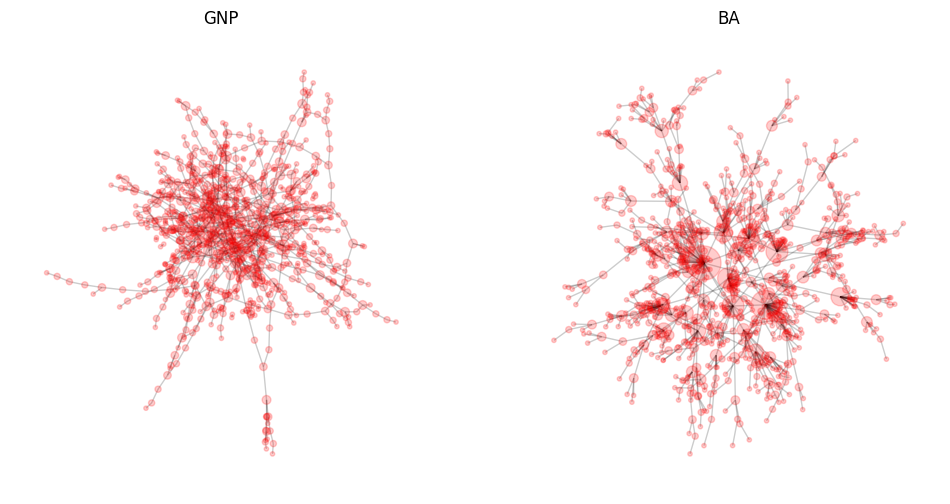

In [3]:
# Set parameters
n = 1000
p = 0.002
m = 1

# Generate ER graph using nx.fast_gnp_random_graph
G_gnp = nx.fast_gnp_random_graph(n, p)

# Generate PA graph using nx.barabasi_albert_graph
G_ba = nx.barabasi_albert_graph(n, m)

# Printing some stats about these networks
print(f"GNP Graph: {G_gnp.number_of_nodes()} nodes, {G_gnp.number_of_edges()} edges")
print(f"BA Graph: {G_ba.number_of_nodes()} nodes, {G_ba.number_of_edges()} edges")

# Plotting them side by side
fig, ax = plt.subplots(figsize = (12, 6), ncols = 2)

for idx, g in enumerate([G_gnp, G_ba]):
    n_dict = dict(g.degree)
    nx.draw(
        g,
        nodelist=n_dict.keys(),
        node_size=[v * 10 for v in n_dict.values()],
        node_color="red",
        alpha=0.2,
        ax=ax[idx]
    )

ax[0].set_title("GNP")
ax[1].set_title("BA")
plt.show()

The above code is just a small recap for you, no need to write any code in there! But for the rest of your code cells we will use the values provided for n, p, and m.

# 2. Random node removal

What are some scenarios where the nodes might get removed?
* Disease control: If random people in a population get sick, does society still function?
* Infrastructure: If random power transformers fail, does the grid collapse?
* Biology: If random proteins get damaged, does the cell survive?

Before we remove any nodes, lets first calculate the giant component of the original network.

To do this, we will use `nx.connected_components`. This function returns a list of connected components as its output. Below is an example of how it works!

[{1, 2, 3, 4, 5, 6}, {8, 9, 10, 7}]


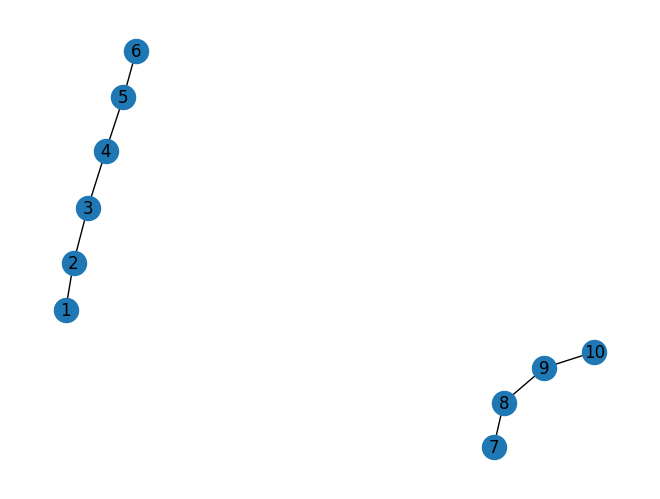

In [4]:
# Run this as is
G = nx.Graph()
G.add_nodes_from([1,2,3,4,5,6,7,8,9,10])
G.add_edges_from([[1,2], [2,3], [3,4], [4,5], [5,6], [7,8], [8,9], [9,10]])
nx.draw(G, with_labels = True)

print(list(nx.connected_components(G))) # The output is a list with sets of nodes in a component

**Understanding this output:**

Each set in the above list represents one connected component. The size of the largest set tells us the giant component. In our example, the giant component has 6 nodes (1-2-3-4-5-6).

Now lets remove a fraction of the nodes from our `G_gnp` graph and see what is our largest connected component.

We will use `np.ranom.choice()` to randomly choose nodes from a list of nodes, then we will remove the chosen nodes using `G.remove_nodes_from()`.

Try filling in the blanks for this code.

In [5]:
f = 0.3  # Remove 30 percent of all edges from our networks

# TODO: Randomly select nodes to remove
node_list = list(G_gnp.nodes())
nodes_to_remove = np.random.choice(a=node_list, replace=False, size=int(f * n))

# TODO: Remove the nodes from G_gnp
G_gnp.remove_nodes_from(nodes_to_remove)

# list with the size of all connected components
SCC = [len(CC) for CC in nx.connected_components(G_gnp)]

# TODO: Print max(SCC)
print(max(SCC) if SCC else 0)


343


For a fully connected network the `largest component = n`, how much did the component size decrease with node removal?


Write your own code to perform the above steps on the `G_ba` network as well, print the largest component size for both `G_gnp` and `G_ba` and compare the results.

In [ ]:
# m_ba: number of edges each new node attaches with (choose ≥1)
m_ba = 3
G_ba = nx.barabasi_albert_graph(n, m_ba)

# Randomly remove a fraction f of nodes (same as before)
ba_node_list = list(G_ba.nodes())
ba_nodes_to_remove = np.random.choice(a=ba_node_list, replace=False, size=int(f * n))
G_ba.remove_nodes_from(ba_nodes_to_remove)

# Size of largest connected component
SCC_ba = [len(cc) for cc in nx.connected_components(G_ba)]
print(max(SCC_ba) if SCC_ba else 0)


692


# 3. Varying the fraction of nodes removed

We just tested one removal scenario (30%). But what if only 10% fail? Or 50%? By testing many fractions, we can find the critical threshold - the point where the network suddenly fragments.

Lets try and vary `f`, increasing it from `0` to `1`, and see how our largest component changes.

**The plan:**
1. Use `np.linspace(0, 0.99, 21)` to create fractions from 0% to 99% (we dont go till `100%` since it might throw an error)
2. For each fraction `f`:
   - Create a random network
   - Remove `f * n` random nodes
   - Find the largest connected component
   - Store its size
3. Plot giant component size vs fraction removed

Below is a FITB version of the code, fill it and use it for both GNP and BA models and store the largest components in `ls_gnp` and `ls_ba`.

NOTE: **What is `np.linspace(start, stop, size)`?**

`np.linspace()` creates an array of evenly spaced numbers of a specified size, the first and final elements of the array are defined by `start` and `stop`.

In [ ]:
ls_gnp = []  # TODO: Define `ls_gnp`

# Sweep fractions f from 0 to 0.90 by 0.05 (adjust as you like)
f_grid = np.arange(0.0, 0.95, 0.05)  # TODO: How many iterations do we need?

for f in f_grid:

    # TODO: Create a GNP network
    G_gnp = nx.gnp_random_graph(n, p)

    # TODO: Find the node list
    node_list = list(G_gnp.nodes())

    # TODO: Randomly select nodes to remove
    nodes_to_remove = np.random.choice(
        a=node_list, replace=False, size=int(f * len(node_list))
    )

    # TODO: Remove the nodes from our graph
    G_gnp.remove_nodes_from(nodes_to_remove)

    # TODO: Find and append the largest connected component to our list
    SCC = [len(CC) for CC in nx.connected_components(G_gnp)]
    ls_gnp.append(max(SCC) if SCC else 0)


# --- Do the same for the BA graph ---
ls_ba = []
for f in f_grid:
    G_ba = nx.barabasi_albert_graph(n, m)  # assumes m is defined (m >= 1)

    ba_nodes = list(G_ba.nodes())
    ba_remove = np.random.choice(
        a=ba_nodes, replace=False, size=int(f * len(ba_nodes))
    )
    G_ba.remove_nodes_from(ba_remove)

    SCC_ba = [len(CC) for CC in nx.connected_components(G_ba)]
    ls_ba.append(max(SCC_ba) if SCC_ba else 0)

Now we can plot `f vs largest component` and see how it changes, we can use `plt.plot(x, y)` to do this.

Try it out below.

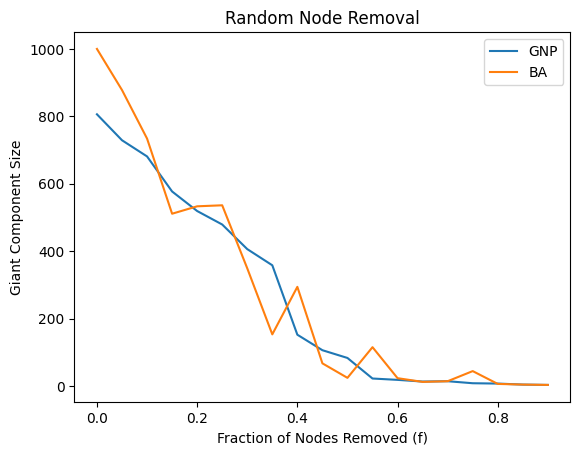

In [8]:
# TODO: Add the lists we should plot
plt.plot(f_grid, ls_gnp, label='GNP')
plt.plot(f_grid, ls_ba, label='BA')

plt.xlabel('Fraction of Nodes Removed (f)')
plt.ylabel('Giant Component Size')
plt.title('Random Node Removal')
plt.legend()
plt.show()

Note: The curves are somewhat rough, to get smoother curves you can average over multiple networks in a single iteration!

# 4. Random edge removal
Why test edge removal separately?

* Node removal: People leaving a company, computers failing.
* Edge removal: Communication links breaking, roads closing, protein interactions disrupted
Different failure modes may affect networks differently!

Now let's try removing edges instead of nodes.

**The plan is similar, but:**
- Instead of removing nodes, remove edges
- Use `np.random.choice(len(list(G.edges())))` to select edge indices
- Convert edges to array: `np.array(G.edges)[indices_to_remove]`
- Use `G.remove_edges_from()` to remove them

So the code for selecting and removing edges becomes:
```python
edges_to_remove = np.random.choice(len(list(G.edges())), 
                                   replace=False, 
                                   size=int(f*G.number_of_edges()))
G.remove_edges_from(np.array(G.edges)[edges_to_remove])
```

Everything else stays the same as node removal, try and adapt your above code to remove the edges and store the largest component in respective lists for both `G_gnp` and `G_ba`.

In [13]:

ls_gnp_edge = []
ls_ba_edge  = []

for f in f_grid:
    # --- GNP ---
    G_gnp = nx.gnp_random_graph(n, p)
    num_e_remove = int(f * G_gnp.number_of_edges())

    # This is the same as what is given above, just a little cleaner.
    edge_arr = np.array(list(G_gnp.edges()))
    idx = np.random.choice(len(edge_arr), replace=False, size=num_e_remove)
    G_gnp.remove_edges_from(edge_arr[idx])

    scc_sizes = [len(cc) for cc in nx.connected_components(G_gnp)]
    ls_gnp_edge.append(max(scc_sizes) if scc_sizes else 0)

    # --- BA ---
    G_ba = nx.barabasi_albert_graph(n, m)
    num_e_remove = int(f * G_ba.number_of_edges())
    
    edge_arr = np.array(list(G_ba.edges()))
    idx = np.random.choice(len(edge_arr), replace=False, size=num_e_remove)
    G_ba.remove_edges_from(edge_arr[idx])
    
    scc_sizes = [len(cc) for cc in nx.connected_components(G_ba)]
    ls_ba_edge.append(max(scc_sizes) if scc_sizes else 0)


Now plot these lists the same way as before, what difference do you notice?

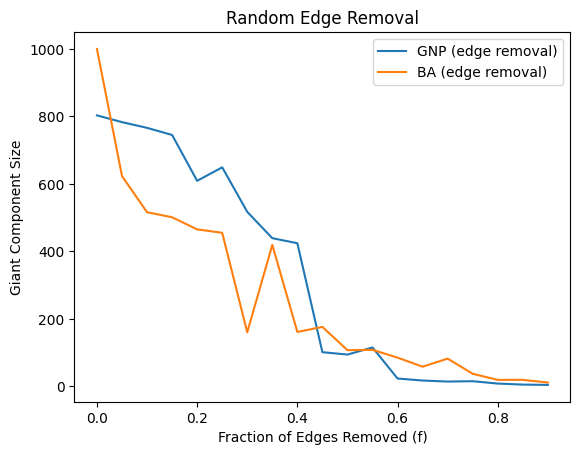

In [14]:
plt.plot(f_grid, ls_gnp_edge, label='GNP (edge removal)')
plt.plot(f_grid, ls_ba_edge,  label='BA (edge removal)')

plt.xlabel('Fraction of Edges Removed (f)')
plt.ylabel('Giant Component Size')
plt.title('Random Edge Removal')
plt.legend()
plt.show()


**Compare your two plots:**

* Are networks more robust to node or edge removal?
* Does this make sense biologically/practically?

1. Generally more robust to random edge removal: removing one edge is usually less damaging than deleting a whole node (which also removes all of its edges).
2. Yes. In real systems (grids, comms, biology), links often fail and systems usually have alt routes; losing an entire node (substation/router/protein) simultaneously removes many links and is more disruptive, so the giant component shrinks faster under node removal than under edge removal.

# Extra Credit! (2 points)

Implement **targeted node removal** where nodes are removed in order of degree (highest first).

Compare BA and GNP network under:
1. Random node removal
2. Targeted degree-based removal

Note: Produce smooth curves by averaging over multiple networks in the same iteration!


In [ ]:
# I've made the helper function and the rest follows
# a straightforward structure I've mostly copied and pasted.

f_grid   = np.arange(0.0, 0.95, 0.05)   # fractions removed
n_trials = 15
np.random.seed(42)                      # reproducible

def largest_component_size(G):
    comps = list(nx.connected_components(G))
    if len(comps) == 0:
        return 0
    return max(len(c) for c in comps)

# -------- RANDOM NODE REMOVAL: GNP --------
gnp_random = []
for f in f_grid:
    total_size = 0
    for _ in range(n_trials):
        G = nx.gnp_random_graph(n, p)
        k = int(f * G.number_of_nodes())
        
        nodes = list(G.nodes())
        remove = np.random.choice(nodes, size=k, replace=False)
        G.remove_nodes_from(remove)
            
        total_size += largest_component_size(G)
    gnp_random.append(total_size / n_trials)

# -------- RANDOM NODE REMOVAL: BA --------
ba_random = []
for f in f_grid:
    total_size = 0
    for _ in range(n_trials):
        G = nx.barabasi_albert_graph(n, m)
        k = int(f * G.number_of_nodes())

        nodes = list(G.nodes())
        remove = np.random.choice(nodes, size=k, replace=False)
        G.remove_nodes_from(remove)

        total_size += largest_component_size(G)
    ba_random.append(total_size / n_trials)

# -------- TARGETED (DEGREE-BASED) REMOVAL: GNP --------
gnp_targeted = []
for f in f_grid:
    total_size = 0
    for _ in range(n_trials):
        G = nx.gnp_random_graph(n, p)
        # rank nodes by degree (highest first)
        deg_list = list(G.degree())
        deg_list.sort(key=lambda x: x[1], reverse=True)
        ranked_nodes = [u for (u, d) in deg_list]

        k = int(f * G.number_of_nodes())
        
        G.remove_nodes_from(ranked_nodes[:k])

        total_size += largest_component_size(G)
    gnp_targeted.append(total_size / n_trials)

# -------- TARGETED (DEGREE-BASED) REMOVAL: BA --------
ba_targeted = []
for f in f_grid:
    total_size = 0
    for _ in range(n_trials):
        G = nx.barabasi_albert_graph(n, m)
        deg_list = list(G.degree())
        deg_list.sort(key=lambda x: x[1], reverse=True)
        ranked_nodes = [u for (u, d) in deg_list]

        k = int(f * G.number_of_nodes())
        
        G.remove_nodes_from(ranked_nodes[:k])

        total_size += largest_component_size(G)
    ba_targeted.append(total_size / n_trials)


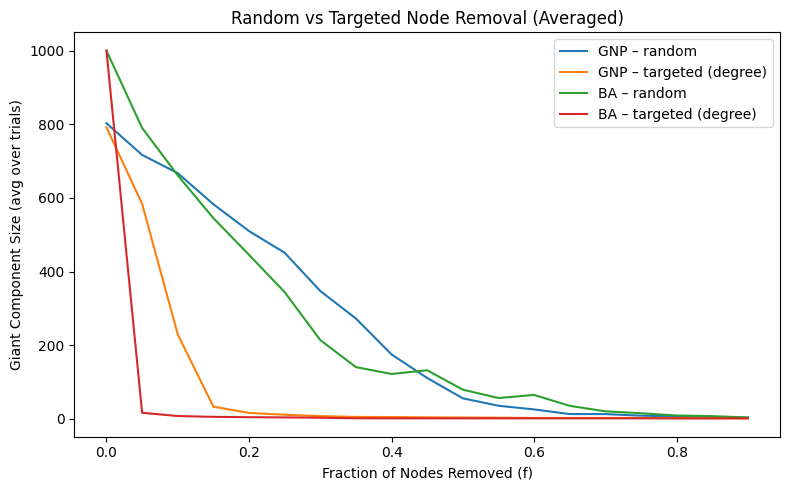

In [19]:
# ---- plot: random vs targeted for each model ----
plt.figure(figsize=(8, 5))
plt.plot(f_grid, gnp_random,   label='GNP – random')
plt.plot(f_grid, gnp_targeted, label='GNP – targeted (degree)')
plt.plot(f_grid, ba_random,    label='BA – random')
plt.plot(f_grid, ba_targeted,  label='BA – targeted (degree)')
plt.xlabel('Fraction of Nodes Removed (f)')
plt.ylabel('Giant Component Size (avg over trials)')
plt.title('Random vs Targeted Node Removal (Averaged)')
plt.legend()
plt.tight_layout()
plt.show()

Expected pattern: BA is robust to random removal but collapses quickly under targeted degree-based removal GNP degrades more smoothly under both, with less dramatic gap between random and targeted.